In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('final_data.csv')
df.head()

,PM2.5 (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³),Toluene (µg/m³),Xylene (µg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),SR (W/mt2),BP (mmHg),VWS (m/s),Month,AQI_Label
0,0.758181,-0.418832,-0.239623,0.398988,-0.687071,0.053854,-0.855273,-0.401137,-1.346117,-2.110376,...,-0.294984,-1.790803,0.773675,-0.882793,-0.318858,-0.694085,1.882801,0.751086,-1.597591,5
1,0.734291,-0.497807,-0.252630,0.622702,-0.808447,-0.040602,-0.834750,-0.434677,-1.348278,-2.135281,...,-0.168583,-1.797989,0.777419,-0.902209,-0.318858,-0.693736,1.878137,0.784631,-1.597591,5
2,0.676191,-0.414993,-0.214215,0.395217,-0.685014,-0.009117,-0.844006,0.219365,-1.328828,-2.143583,...,0.570072,-1.806374,0.776349,-0.863376,0.122589,-0.692898,1.882801,0.751086,-1.597591,5
3,0.648375,-0.483548,-0.271081,0.620188,-0.954509,-0.056345,-0.851249,0.185824,-1.343956,-2.019058,...,0.629322,-1.812362,0.770466,-0.902209,0.352559,-0.692689,1.876582,0.751086,-1.597591,5
4,0.618428,-0.510970,-0.272896,0.411556,-0.956566,-0.040602,-0.856883,-0.375981,-1.393662,-1.990002,...,-0.081683,-1.819549,0.769396,-0.630376,-0.341144,-0.693038,1.856371,0.717541,-1.597591,5


In [2]:
df.shape

(8784, 21)

In [ ]:
#Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['AQI_Label'])
y = df['AQI_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(7027, 20)
(1757, 20)


In [5]:
#training logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Training Accuracy:", lr_model.score(X_train, y_train))
print("Testing Accuracy:", lr_model.score(X_test, y_test))

Training Accuracy: 0.9193112281201081
Testing Accuracy: 0.9038133181559477


In [6]:
#evaluating precision , recall, f1-score

from sklearn.metrics import classification_report, confusion_matrix

y_pred = lr_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.84      0.89       242
           1       0.87      0.88      0.87       348
           2       0.85      0.79      0.82       163
           3       0.87      0.93      0.90       493
           4       0.98      0.93      0.95       111
           5       0.96      0.96      0.96       400

    accuracy                           0.90      1757
   macro avg       0.91      0.89      0.90      1757
weighted avg       0.91      0.90      0.90      1757



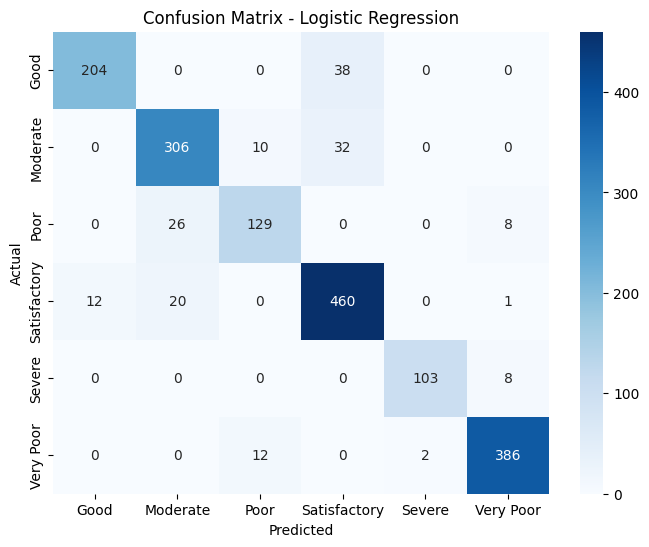

In [9]:
#confusion matrix 
labels = ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

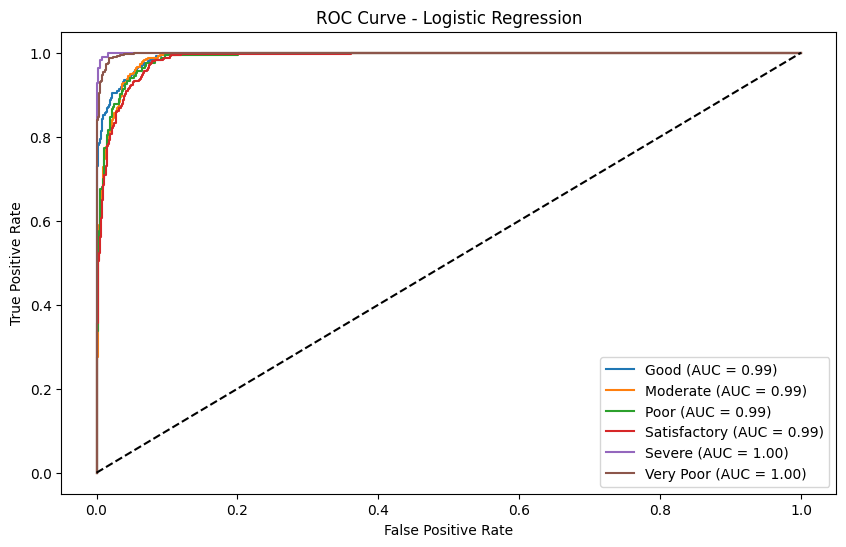

In [10]:
#ROC Curve 

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels
classes = [0, 1, 2, 3, 4, 5]
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_prob = lr_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(10, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()